### want to do CCGP, Jahn et al analyses for selected stim feature, conditioned on different belief states. 
want to make sure we have enough trials for each condition. 
- look at the feat session pairs.
    - for each feature session pair, count the number of trials in each of the 6 conditions.
    - across all feat/sess pairs, plot histograms of each of the 6 conditions

In [2]:
%load_ext autoreload
%autoreload 2

import os
import numpy as np
import pandas as pd
import utils.behavioral_utils as behavioral_utils
import utils.information_utils as information_utils
import utils.visualization_utils as visualization_utils
import utils.pseudo_classifier_utils as pseudo_classifier_utils
import utils.classifier_utils as classifier_utils

import utils.io_utils as io_utils

import utils.glm_utils as glm_utils
from matplotlib import pyplot as plt
import matplotlib
import utils.spike_utils as spike_utils
import utils.subspace_utils as subspace_utils
from trial_splitters.condition_trial_splitter import ConditionTrialSplitter 
from utils.session_data import SessionData
from constants.behavioral_constants import *
from constants.decoding_constants import *
import seaborn as sns
from scripts.anova_analysis.anova_configs import *
from scripts.anova_analysis.run_anova import load_data
import scipy
import argparse
import copy
from spike_tools import (
    general as spike_general,
    analysis as spike_analysis,
)
import itertools
from tqdm import tqdm

In [2]:
feats = []
for sub in ["SA", "BL"]:
    FEATS_PATH = f"/data/patrick_res/sessions/{sub}/feats_at_least_3blocks.pickle"
    sub_feats = pd.read_pickle(FEATS_PATH)
    sub_feats["subject"] = sub
    feats.append(sub_feats)
feats = pd.concat(feats)

In [3]:

def get_counts_by_belief_partition_and_choice(sub, session, feat):
    beh = behavioral_utils.get_valid_belief_beh_for_sub_sess(sub, session)
    beh = behavioral_utils.get_feat_choice_label(beh, feat)
    beh = behavioral_utils.get_belief_partitions(beh, feat, use_x=True)
    counts = beh.groupby(["BeliefPartition", "Choice"]).TrialNumber.count().reset_index(name="Count")
    counts["feat"] = feat
    counts["session"] = session
    counts["sub"] = sub
    return counts

In [4]:
res = pd.concat(feats.explode("sessions").apply(lambda row: get_counts_by_belief_partition_and_choice(row["subject"], row["sessions"], row["feat"]), axis=1).values)

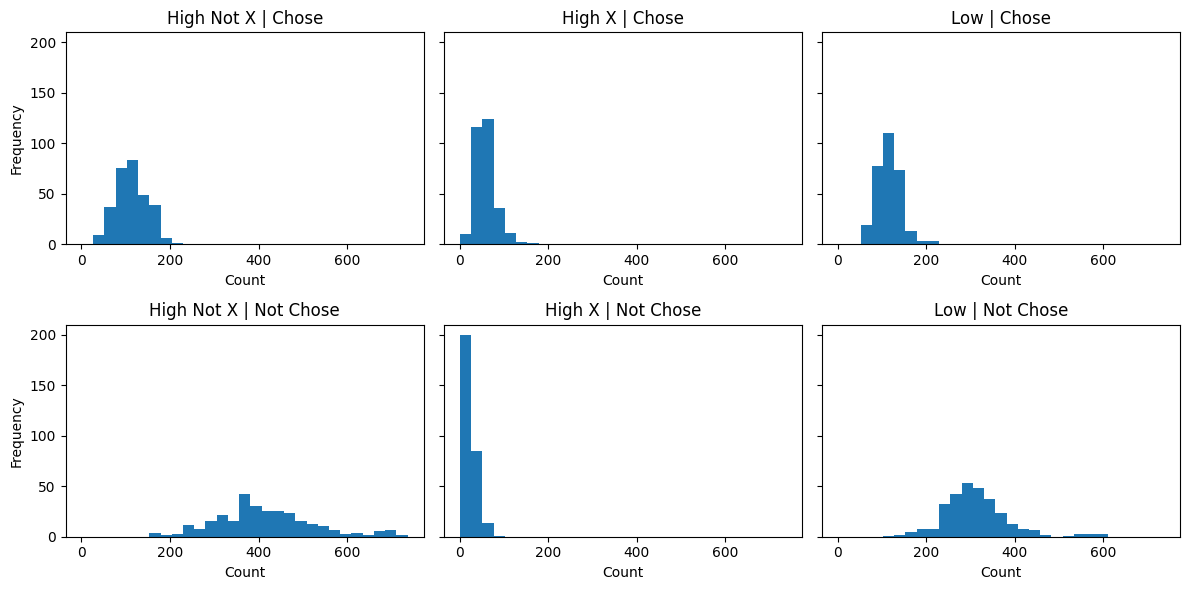

In [5]:
belief_partitions = ["High Not X", "High X", "Low"]
choices = ["Chose", "Not Chose"]

count_min = res["Count"].min()
count_max = res["Count"].max()
bins = np.linspace(count_min, count_max, 30)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)

for row_idx, choice in enumerate(choices):
    for col_idx, bp in enumerate(belief_partitions):
        ax = axes[row_idx, col_idx]
        data = res[(res["Choice"] == choice) & (res["BeliefPartition"] == bp)]["Count"]
        ax.hist(data, bins=bins)
        ax.set_title(f"{bp} | {choice}")
        ax.set_xlabel("Count")
        if col_idx == 0:
            ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()

### What if looking at to dim-based beliefs?
For single features, it seems like the issue is not enough trials with High X, Not chose X. 
What about for dimensions of beliefs?


Look at one session first: 

In [4]:
beh = behavioral_utils.get_valid_belief_beh_for_sub_sess("SA", "20180802")

In [5]:
def get_belief_dim_partition(beh, thresh=BELIEF_PARTITION_THRESH):
    def label_trial(row):
        if row.PreferredBeliefProb <= thresh: 
            return "Low"
        else: 
            return FEATURE_TO_DIM[row.PreferredBelief]
    beh["BeliefDimPartition"] = beh.apply(label_trial, axis=1)
    return beh


In [6]:
beh = get_belief_dim_partition(beh)

In [7]:
beh["BeliefDimPartition"].unique()

array(['Low', 'Shape', 'Pattern', 'Color'], dtype=object)

Text(0.0, 1.0, 'Belief in in other dimension is High')

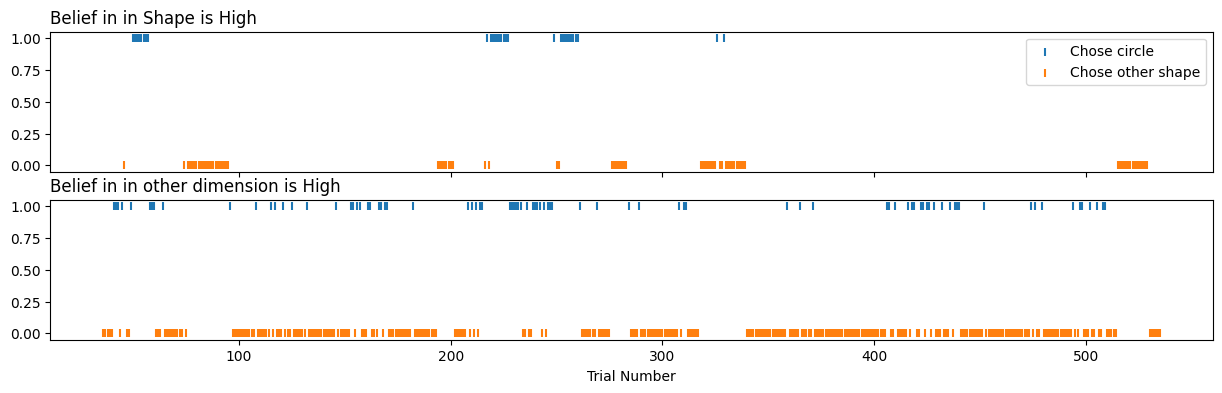

In [17]:
fig, axs = plt.subplots(2, 1, figsize=(15, 4), sharex=True)
beh = beh[:500]
sub_beh = beh[(beh.Shape == "CIRCLE") & (beh.BeliefDimPartition == "Shape")]
axs[0].scatter(sub_beh.TrialNumber, [1]*len(sub_beh), label="Chose circle", marker="|")
sub_beh = beh[(beh.Shape != "CIRCLE") & (beh.BeliefDimPartition == "Shape")]
axs[0].scatter(sub_beh.TrialNumber, [0]*len(sub_beh), label="Chose other shape", marker="|")
axs[0].legend()
axs[0].set_title("Belief in in Shape is High", loc="left")

sub_beh = beh[(beh.Shape == "CIRCLE") & (beh.BeliefDimPartition != "Shape")]
axs[1].scatter(sub_beh.TrialNumber, [1]*len(sub_beh), label="Chose circle", marker="|")
sub_beh = beh[(beh.Shape != "CIRCLE") & (beh.BeliefDimPartition != "Shape")]
axs[1].scatter(sub_beh.TrialNumber, [0]*len(sub_beh), label="Chose other shape", marker="|")
axs[1].set_xlabel("Trial Number")
axs[1].set_title("Belief in in other dimension is High", loc="left")


### Generate counts of trials for the per dimension analyses

In [4]:
feats = []
for sub in ["SA", "BL"]:
    FEATS_PATH = f"/data/patrick_res/sessions/{sub}/feats_at_least_3blocks.pickle"
    sub_feats = pd.read_pickle(FEATS_PATH)
    sub_feats["subject"] = sub
    feats.append(sub_feats)
feats = pd.concat(feats)

In [5]:
def get_counts_by_belief_partition_and_choice(sub, session, feat):
    beh = behavioral_utils.get_valid_belief_beh_for_sub_sess(sub, session)
    beh = behavioral_utils.get_feat_choice_label(beh, feat)
    beh = behavioral_utils.get_belief_dim_partition(beh, feat, use_x=True)
    counts = beh.groupby(["BeliefDimPartition", "Choice"]).TrialNumber.count().reset_index(name="Count")
    counts["feat"] = feat
    counts["session"] = session
    counts["sub"] = sub
    return counts

In [6]:
res = pd.concat(feats.explode("sessions").apply(lambda row: get_counts_by_belief_partition_and_choice(row["subject"], row["sessions"], row["feat"]), axis=1).values)

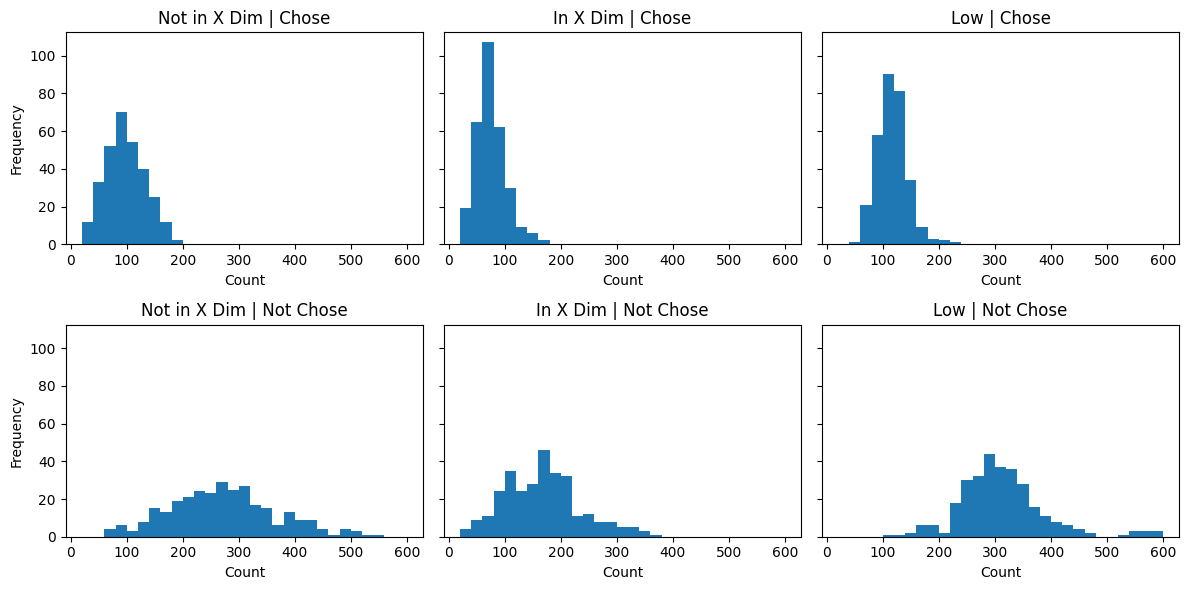

In [7]:
belief_dim_partitions = ["Not in X Dim", "In X Dim", "Low"]
choices = ["Chose", "Not Chose"]

count_min = res["Count"].min()
count_max = res["Count"].max()
bins = np.linspace(count_min, count_max, 30)

fig, axes = plt.subplots(2, 3, figsize=(12, 6), sharey=True)

for row_idx, choice in enumerate(choices):
    for col_idx, bp in enumerate(belief_dim_partitions):
        ax = axes[row_idx, col_idx]
        data = res[(res["Choice"] == choice) & (res["BeliefDimPartition"] == bp)]["Count"]
        ax.hist(data, bins=bins)
        ax.set_title(f"{bp} | {choice}")
        ax.set_xlabel("Count")
        if col_idx == 0:
            ax.set_ylabel("Frequency")

plt.tight_layout()
plt.show()